# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the IBM Telco Customer Churn dataset through statistical summaries and visualizations. The analysis focuses on understanding customer characteristics, identifying churn patterns, and discovering relationships between different variables that may influence customer retention.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [3]:
print("Dataset Shape :", df.shape)
print("\nRows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Dataset Shape : (7043, 50)

Rows : 7043
Columns : 50
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip

##  Churn Distribution

This visualization shows the overall distribution of customers who stayed and customers who churned.

In [47]:
import plotly.express as px

fig = px.histogram(
    df,
    x="Churn Label",
    color="Churn Label",
    text_auto=True,
    title="Customer Churn Distribution",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(template="plotly_white")
fig.show()

##  Gender Distribution

In [5]:
fig = px.histogram(
    df,
    x="Gender",
    color="Gender",
    text_auto=True,
    title="Gender Distribution"
)

fig.update_layout(template="plotly_white")

fig.show()

##  Age Distribution

In [7]:
fig = px.histogram(
    df,
    x="Age",
    nbins=30,
    title="Age Distribution"
)

fig.update_layout(template="plotly_white")

fig.show()

## Senior Citizen Distribution

C:\Users\nidhi\AppData\Local\Temp\ipykernel_13252\2617752661.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




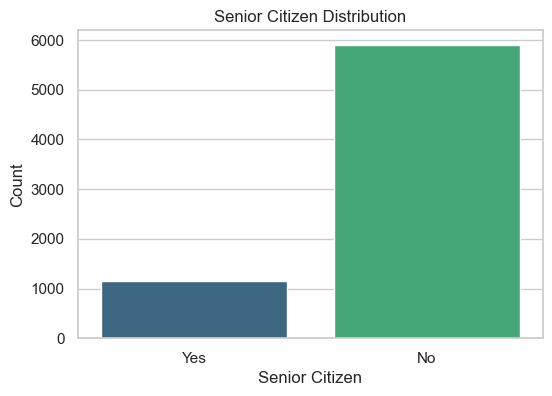

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Senior Citizen", palette="viridis")

plt.title("Senior Citizen Distribution")
plt.xlabel("Senior Citizen")
plt.ylabel("Count")

plt.show()

### Observation

- Most customers are non-senior citizens, while senior citizens represent a smaller portion of the customer base.

## Contract Type Distribution

C:\Users\nidhi\AppData\Local\Temp\ipykernel_13252\2790100613.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




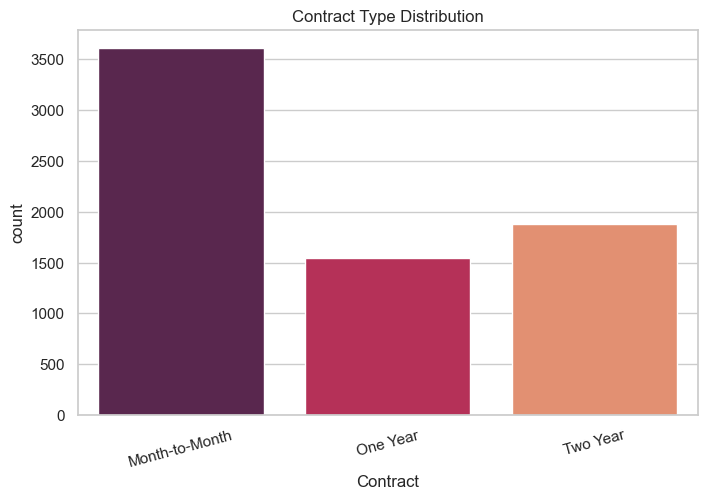

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    palette="rocket"
)

plt.title("Contract Type Distribution")
plt.xticks(rotation=15)

plt.show()

### Observation
- Month-to-month contracts are the most common among customers.

# Internet Service Distribution

C:\Users\nidhi\AppData\Local\Temp\ipykernel_13252\1161714933.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




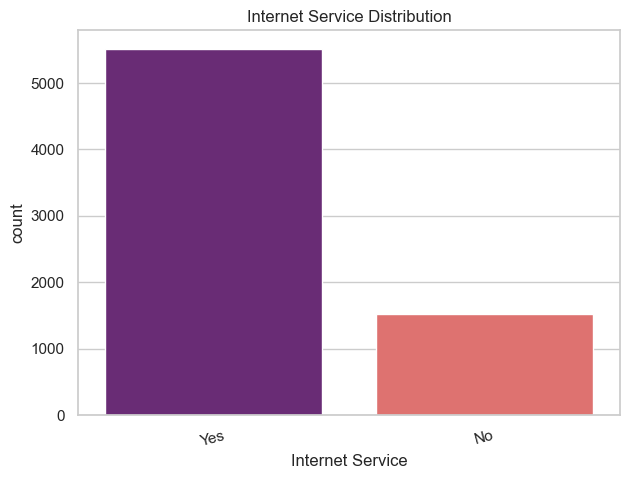

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Internet Service",
    palette="magma"
)

plt.title("Internet Service Distribution")

plt.xticks(rotation=15)

plt.show()

### Observation

- Fiber Optic and DSL are the most widely used internet services.

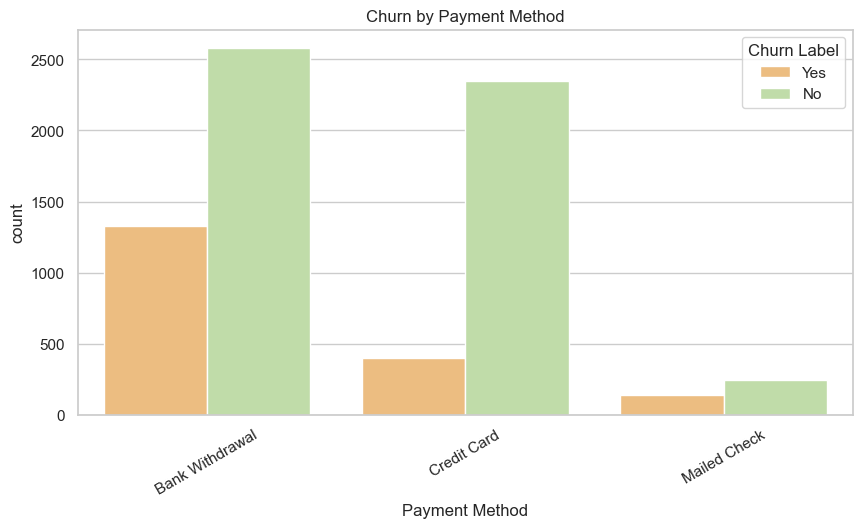

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label",
    palette="Spectral"
)

plt.xticks(rotation=30)

plt.title("Churn by Payment Method")

plt.show()

### Observation

- Customers using Electronic Check tend to churn more frequently than customers using automatic payment methods.

# Tenure Distribution

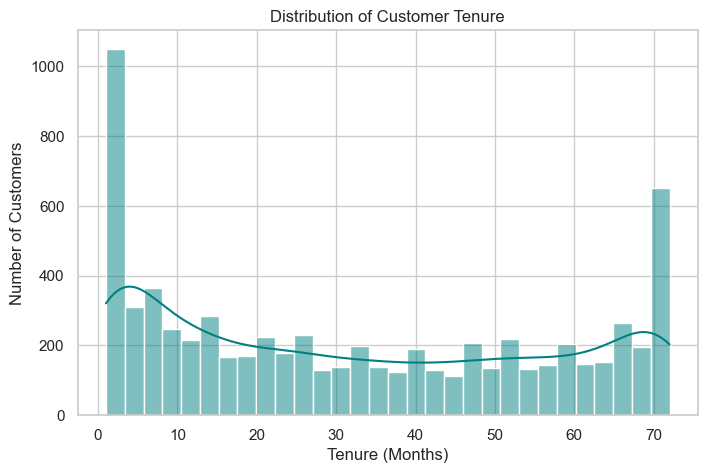

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Tenure in Months"],
    bins=30,
    kde=True,
    color="teal"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- A large number of customers have relatively short tenure, while long-term customers are fewer.

## Monthly Charge Distribution

This visualization shows the distribution of monthly charges across all customers.

In [50]:
# Monthly Charge Distribution

fig = px.histogram(
    df,
    x="Monthly Charge",
    nbins=30,
    title="Distribution of Monthly Charges",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Monthly Charge",
    yaxis_title="Number of Customers"
)

fig.show()

# Total Charges Distribution

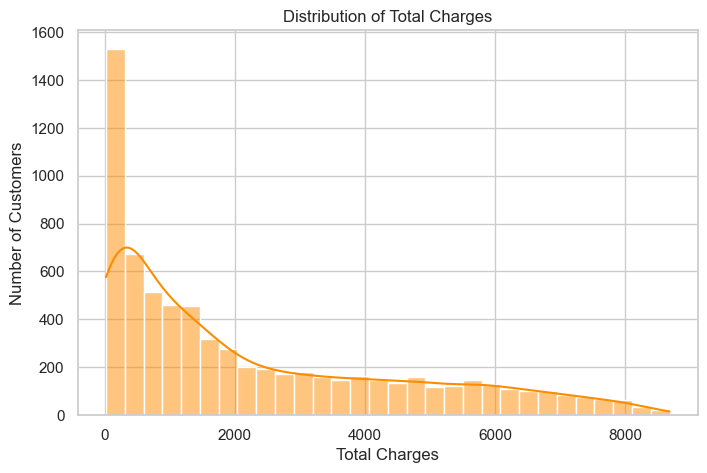

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total Charges"],
    bins=30,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

## Monthly Charges vs Churn

This visualization compares the monthly charges of customers based on their churn status.

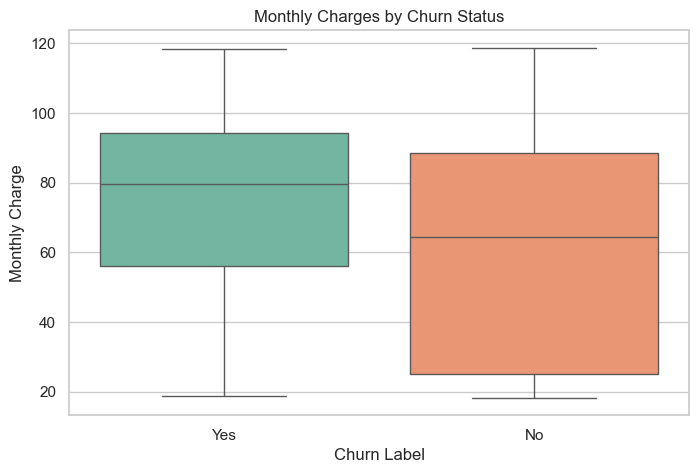

In [ ]:
# Monthly Charges vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charge",
    hue="Churn Label",
    palette="Set2",
    legend=False
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Label")
plt.ylabel("Monthly Charge")

plt.show()

### Observation

Customers who churn generally have higher monthly charges compared to customers who stay with the company.

## Total Charges vs Churn

This visualization compares the total charges of customers based on churn status.

C:\Users\nidhi\AppData\Local\Temp\ipykernel_13252\779493221.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




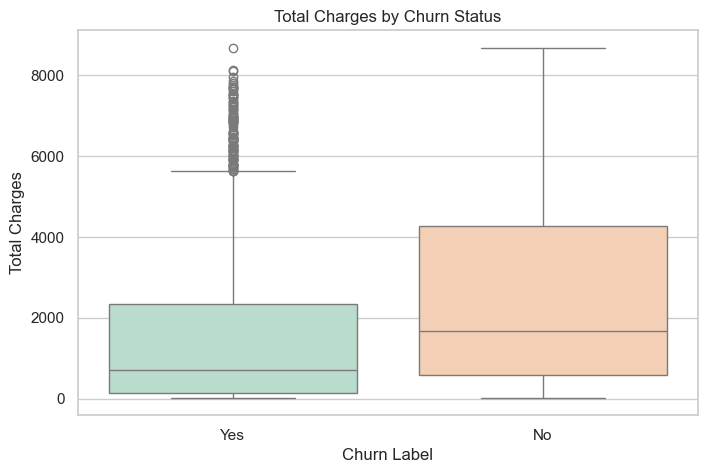

In [29]:
# Convert Total Charges to numeric

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Total Charges vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Total Charges",
    palette="Pastel2"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn Label")
plt.ylabel("Total Charges")

plt.show()

### Observation

Customers who stayed with the company generally have higher total charges because they tend to remain subscribed for a longer period.

## Married vs Churn

This chart compares customer churn based on marital status.

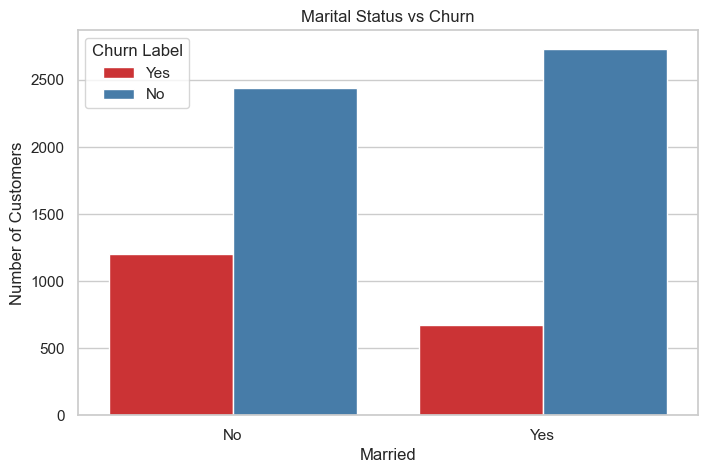

In [30]:
# Married vs Churn

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Married",
    hue="Churn Label",
    palette="Set1"
)

plt.title("Marital Status vs Churn")
plt.xlabel("Married")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Married customers appear to have a lower churn rate than unmarried customers.

## Dependents vs Churn

This chart compares churn between customers with and without dependents.

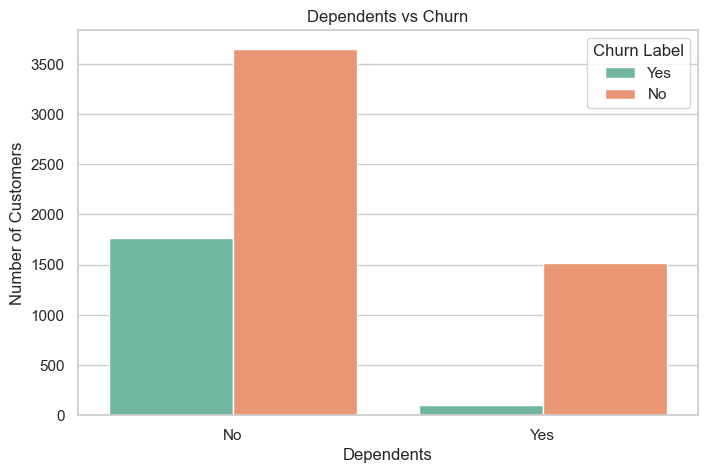

In [31]:
# Dependents vs Churn

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn Label",
    palette="Set2"
)

plt.title("Dependents vs Churn")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Customers with dependents tend to remain with the company more often than customers without dependents.

## Online Security vs Churn

This visualization shows the relationship between online security service and customer churn.

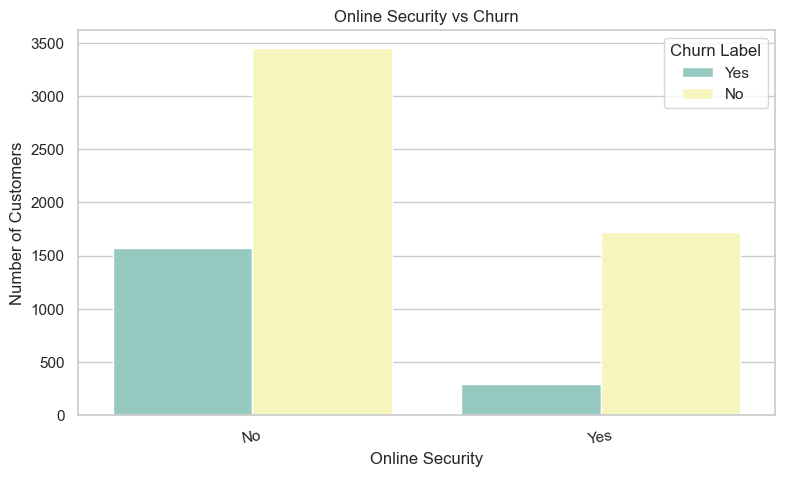

In [32]:
# Online Security vs Churn

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Online Security",
    hue="Churn Label",
    palette="Set3"
)

plt.title("Online Security vs Churn")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.xticks(rotation=10)

plt.show()

### Observation

Customers without online security services show a higher churn rate than those who have the service.

## Premium Tech Support vs Churn

This chart shows how premium technical support influences customer churn.

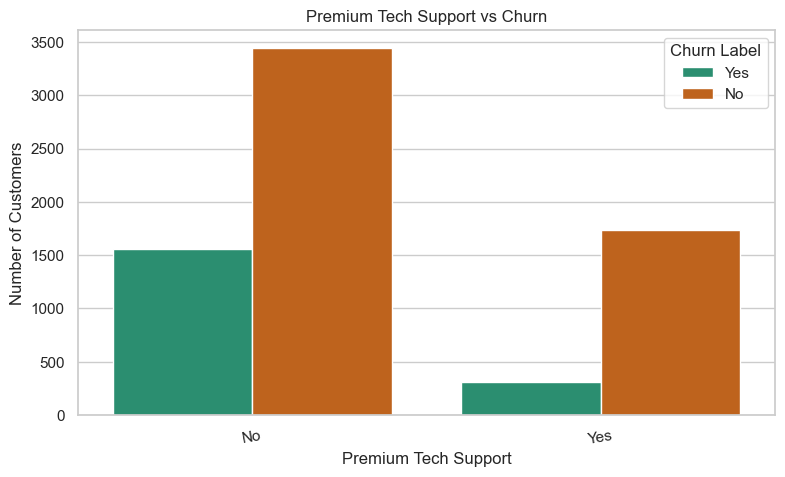

In [33]:
# Premium Tech Support vs Churn

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Premium Tech Support",
    hue="Churn Label",
    palette="Dark2"
)

plt.title("Premium Tech Support vs Churn")
plt.xlabel("Premium Tech Support")
plt.ylabel("Number of Customers")

plt.xticks(rotation=10)

plt.show()

### Observation

Customers who receive premium technical support are less likely to churn compared to customers without technical support.

## Device Protection Plan vs Churn

This visualization compares customer churn based on device protection plan availability.

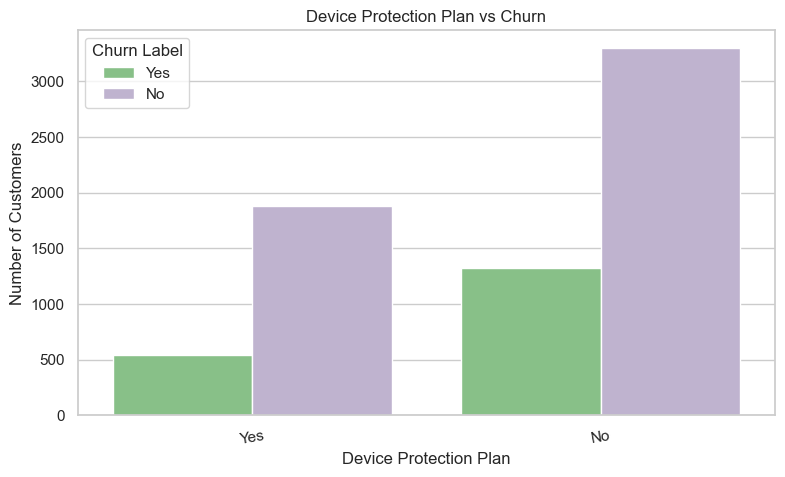

In [34]:
# Device Protection Plan vs Churn

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Device Protection Plan",
    hue="Churn Label",
    palette="Accent"
)

plt.title("Device Protection Plan vs Churn")
plt.xlabel("Device Protection Plan")
plt.ylabel("Number of Customers")

plt.xticks(rotation=10)

plt.show()

### Observation

Customers who subscribe to a device protection plan tend to have a lower churn rate.

## Gender vs Churn

This visualization compares customer churn across different gender groups.

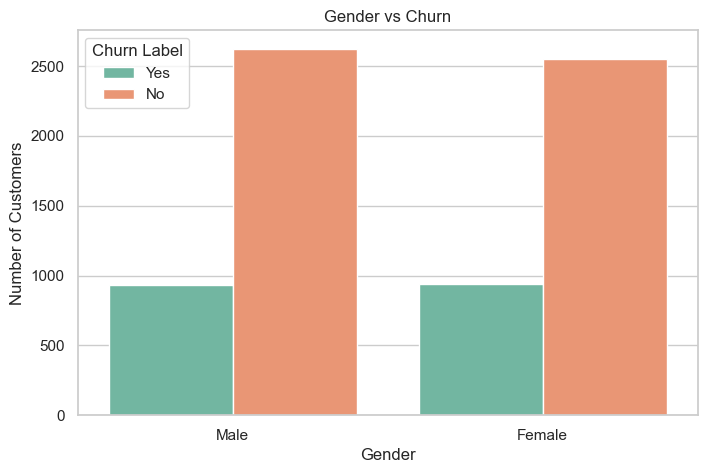

In [40]:
# Gender vs Churn

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Churn Label",
    palette="Set2"
)

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The churn pattern is relatively similar across both genders, indicating that gender alone is not a strong predictor of customer churn.

## Senior Citizen vs Churn

This visualization compares churn among senior and non-senior customers.

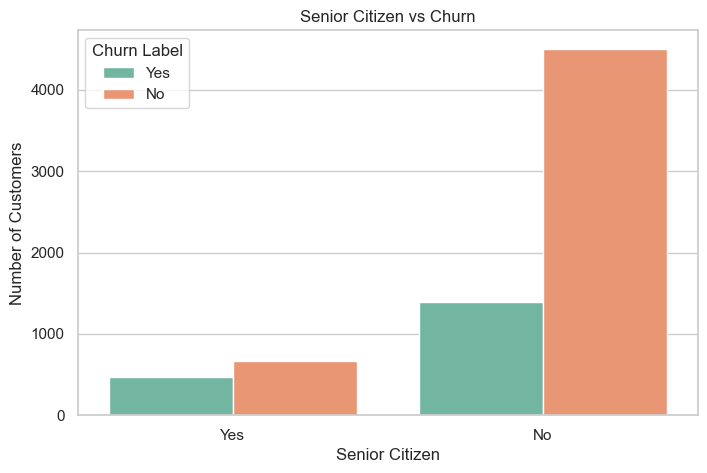

In [41]:
# Senior Citizen vs Churn

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Senior Citizen",
    hue="Churn Label",
    palette="Set2"
)

plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Senior citizens show a higher proportion of churn compared to non-senior customers.

## Contract Type vs Churn

This visualization compares customer churn across different contract types.

In [48]:
# Contract Type vs Churn

fig = px.histogram(
    df,
    x="Contract",
    color="Churn Label",
    barmode="group",
    text_auto=True,
    title="Contract Type vs Churn",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(template="plotly_white")

fig.show()

### Observation

Customers with month-to-month contracts have a noticeably higher churn rate than customers with one-year or two-year contracts.

## Internet Service vs Churn

This visualization compares churn across different internet service categories.

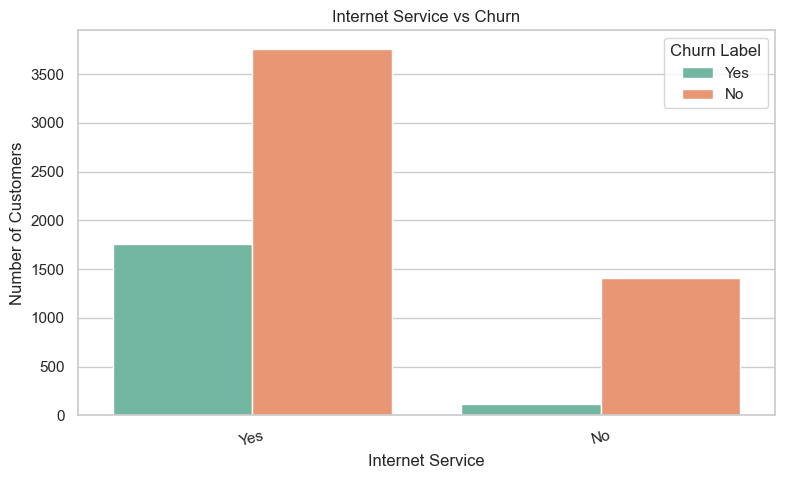

In [ ]:
# Internet Service vs Churn

fig = px.histogram(
    df,
    x="Internet Service",
    color="Churn Label",
    barmode="group",
    text_auto=True,
    title="Internet Service vs Churn",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(template="plotly_white")

fig.show()

### Observation

Customers using Fiber Optic internet service tend to have a higher churn rate than customers using other internet service types.

## Payment Method vs Churn

This visualization compares churn across different payment methods.

In [49]:
# Payment Method vs Churn

fig = px.histogram(
    df,
    x="Payment Method",
    color="Churn Label",
    barmode="group",
    text_auto=True,
    title="Payment Method vs Churn",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-30
)

fig.show()

### Observation

Electronic check users show a relatively higher churn rate than customers using automatic payment methods.

## Tenure vs Churn

This visualization compares customer tenure based on churn status.

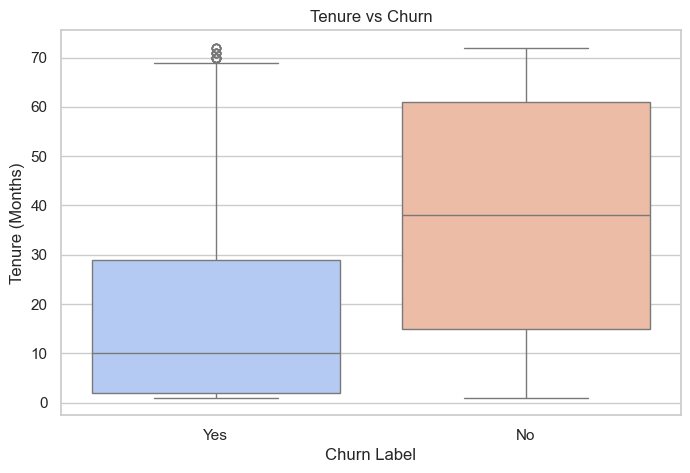

In [45]:
# Tenure vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure in Months",
    hue="Churn Label",
    palette="coolwarm",
    legend=False
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("Tenure (Months)")

plt.show()

### Observation

Customers who churn generally have a shorter tenure, while long-term customers are more likely to remain with the company.

## Correlation Heatmap

The correlation heatmap helps identify relationships between numerical variables in the dataset. Strong positive or negative correlations can provide useful insights for feature selection and model development.

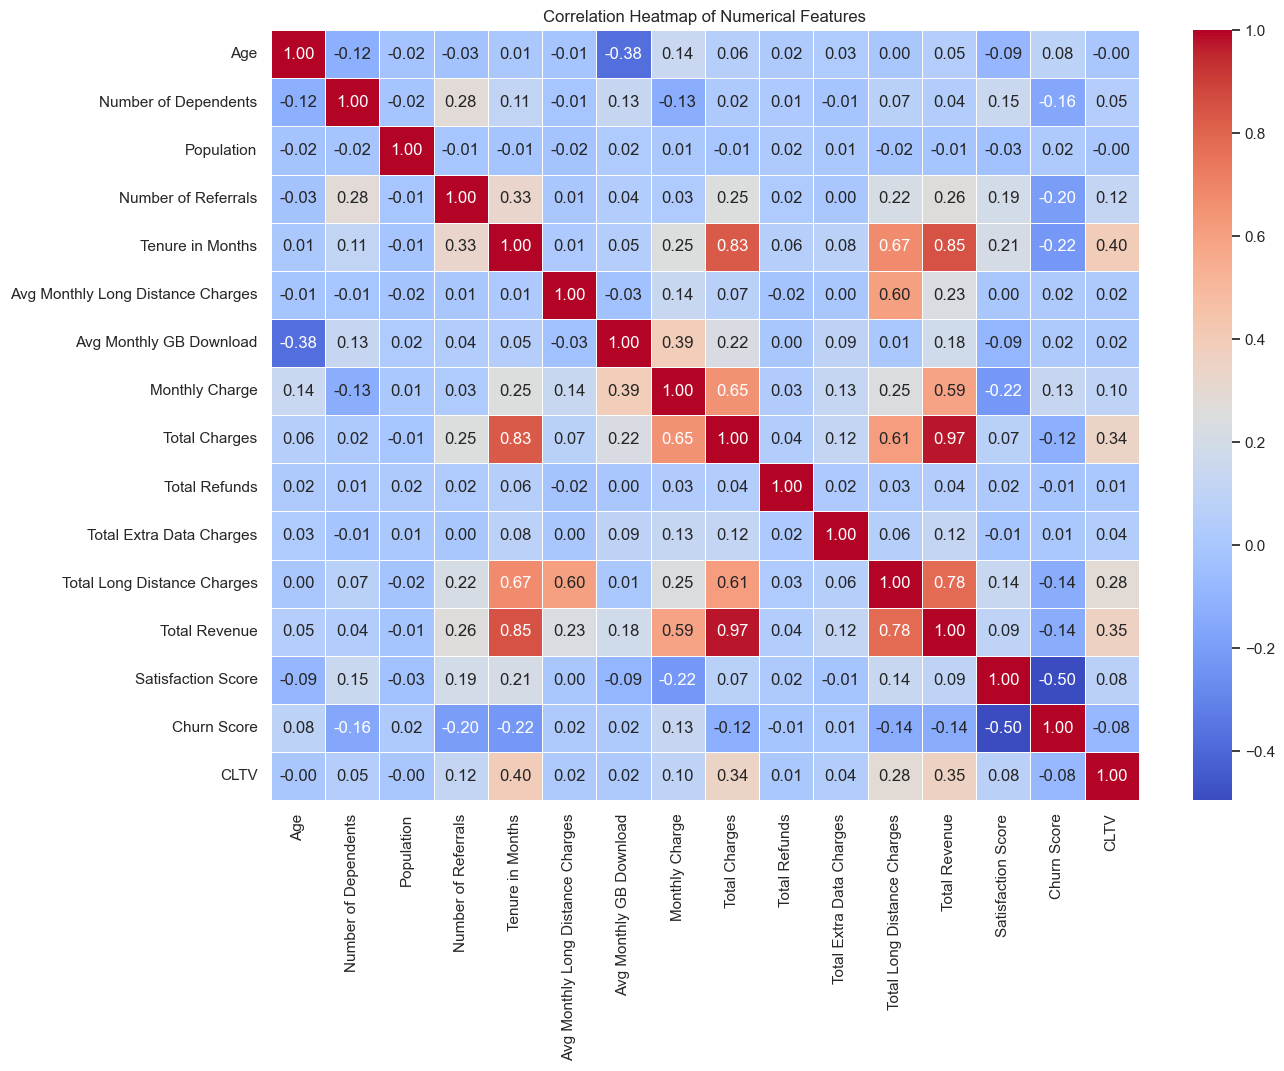

In [46]:
# Select Numerical Features

numerical_features = [
    "Age",
    "Number of Dependents",
    "Population",
    "Number of Referrals",
    "Tenure in Months",
    "Avg Monthly Long Distance Charges",
    "Avg Monthly GB Download",
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Revenue",
    "Satisfaction Score",
    "Churn Score",
    "CLTV"
]

# Correlation Matrix

correlation_matrix = df[numerical_features].corr()

# Plot Heatmap

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Observation

Most numerical variables exhibit weak to moderate correlations. Features such as Total Revenue, Total Charges, Monthly Charge, and Tenure in Months demonstrate stronger relationships and are expected to contribute significantly during model training.

# Key Business Insights

1. Customers with month-to-month contracts exhibit the highest churn rate.

2. Senior citizens are more likely to churn than non-senior customers.

3. Customers with higher monthly charges tend to leave the service more frequently.

4. Long-term customers generally remain loyal and show lower churn rates.

5. Customers without online security services have a higher probability of churning.

6. Premium technical support is associated with improved customer retention.

7. Customers without dependents appear more likely to churn than those with dependents.

8. Electronic check users show a relatively higher churn rate compared to customers using automatic payment methods.

9. Customers subscribed to device protection services tend to remain with the company longer.

10. The exploratory analysis indicates that contract type, tenure, monthly charges, internet services, and support-related features are among the strongest indicators of customer churn.